<a href="https://colab.research.google.com/github/ikoghoddds-bit/Data-Science-Portfolio-C21/blob/main/Projects/Project-6/Images-Description.for.Students_Pass_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Image Classification with Deep Learning



This project introduces us to deep learning. The deep learning process is a huge leap forward in data science and the field is less than 15 years old. The processing is significantly different from our previous projects so you will basically be provided a walkthrough document delineating the steps - much like Project 1. Deep learning is fascinating and I just want you to go through the process so you can appreciate its power.



The data collection portion of deep learning projects is a rather complex task. In other words, there is no CSV file that we can load to serve as our training data. Constructing a training data set is a rather large undertaking. We have imported all the training images (took hours) and I will show you how you can load the training data through the "pickle" process.



There are three files in this data set:
- [the feature set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle ), i.e. images of dogs and cats ( mostly )
- [the target set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle ), i.e. the label (0/1) that something is a dog or cat ( mostly )
- [a test image]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg )





This project will classify new, unseen images of cats and dogs. This was one of the first big success stories of deep learning and we will go through the process of building a learning algorithm that will do this task. Distinguishing a picture of a cat from a picture of a dog is easy for humans to do, but had been notoriously difficult to get a computer learning to perform well on the task. Deep learning solved that.


The same data sets as above, but you can copy the links by viewing the markdown directly to bypass Google Colab's annoying "You are leaving Colab" link.




https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg


In [1]:
import pandas as pd


In [2]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [3]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [4]:
image_array.shape

(24946, 100, 100, 1)

In [5]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [6]:
target = pd.read_pickle( target_url )
type(target)


list

In [7]:
image_url = ''

## Library Imports

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
import urllib.request
import cv2

## Verify GPU Enabled

In [9]:
# Verify GPU is enabled and detected by TensorFlow

print("GPU Devices Available: ", tf.config.list_physical_devices('GPU'))

GPU Devices Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Collection

### Load Pickled Data

In [11]:
# Load the Pickled Data

X_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
y_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"

X_full = pd.read_pickle(X_url)
y_full = np.array(pd.read_pickle(y_url))

In [12]:
# Subsample for Pass 7 (ALL images, randomized)

np.random.seed(42)
indices = np.arange(len(X_full))
np.random.shuffle(indices)

# USING ALL IMAGES

X_subset = X_full[indices]
y_subset = y_full[indices]

# Data Cleaning (Scaling)

X_subset = X_subset / 255.0

### Exploratory Data Analysis (EDA)

X_subset will now reflect the complete shape of the raw data.

In [13]:
# Verify Dimensionality

print(f"X_subset shape: {X_subset.shape}") # Should be (24946, 100, 100, 1)
print(f"y_subset shape: {y_subset.shape}") # Should be (24946,)

X_subset shape: (24946, 100, 100, 1)
y_subset shape: (24946,)


### Visual Inspection and Label Verification

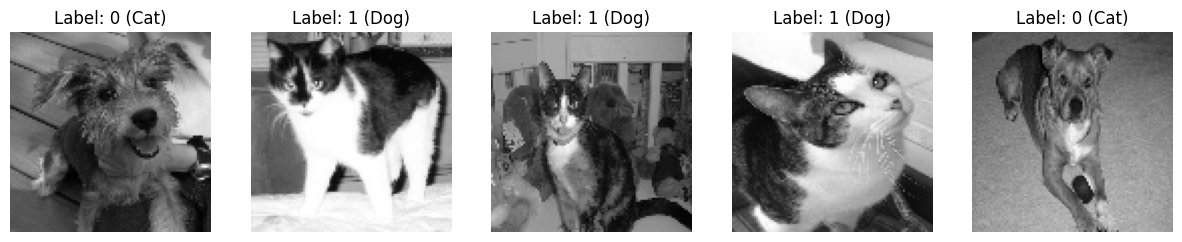

In [14]:
# Visual Inspection and Label Verification

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_subset[i].reshape(100, 100), cmap='gray')
    label = "Dog" if y_subset[i] == 1 else "Cat"
    plt.title(f"Label: {y_subset[i]} ({label})")
    plt.axis('off')
plt.show()

## CNN Architecture & Compilation

#### Maintaining the baseline architecture to measure the final metrics of the required project constraints.

### Train_Test Split

In [15]:
# Train-Test Split (80/20 split)

# This results in roughly 19,956 training images and 4,990 testing images

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.20, random_state=42
)

# Build the Sequential Model

model = Sequential()

# Add Convolutional Blocks

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(100, 100, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Define the Output Layer

model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# Compile the Engine

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        33,857 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,673 (205.75 KB)

 Trainable params: 52,673 (205.75 KB)

 Non-trainable params: 0 (0.00 B)

## Training and Prediction

### Fitting The Model

In [16]:
# Fit the Model

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

# Evaluate Performance

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# External Prediction Function

def predict_external_image(image_url, current_model):
    req = urllib.request.urlopen(image_url)
    arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)

    img_resized = cv2.resize(img, (100, 100))
    img_scaled = img_resized / 255.0
    img_reshaped = img_scaled.reshape(1, 100, 100, 1)

    prediction = current_model.predict(img_reshaped)[0][0]
    predicted_class = "Dog" if prediction > 0.5 else "Cat"

    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Prediction: {predicted_class} (Prob: {prediction:.4f})")
    plt.axis('off')
    plt.show()

Epoch 1/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6793 - loss: 0.5859 - val_accuracy: 0.7461 - val_loss: 0.5156
Epoch 2/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7631 - loss: 0.4895 - val_accuracy: 0.7647 - val_loss: 0.4877
Epoch 3/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7979 - loss: 0.4358 - val_accuracy: 0.7914 - val_loss: 0.4481
Epoch 4/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8232 - loss: 0.3935 - val_accuracy: 0.7988 - val_loss: 0.4451
Epoch 5/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8455 - loss: 0.3520 - val_accuracy: 0.8016 - val_loss: 0.4316
Epoch 6/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8649 - loss: 0.3171 - val_accuracy: 0.7980 - val_loss: 0.4477
Epoch 7/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8779 - loss: 0.2863 - val_accuracy: 0.7966 - val_loss: 0.4502
Epoch 8/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8940 - loss: 0.2544 - val_accur

## Testing Model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step


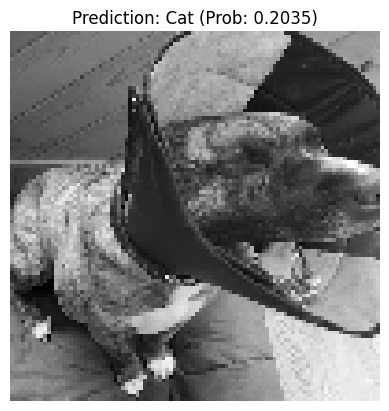

In [17]:
# Test the function with the provided dog image

dog_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"
predict_external_image(dog_url, model)

## Pass 2 Analytical Review

With all 24,946 images, the distributions is at their most optimized state, with the vast majority of predictions clustered tightly at the extreme ends of the probability spectrum

In [18]:
# Generate predictions for the test set

test_predictions = model.predict(X_test).flatten()

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


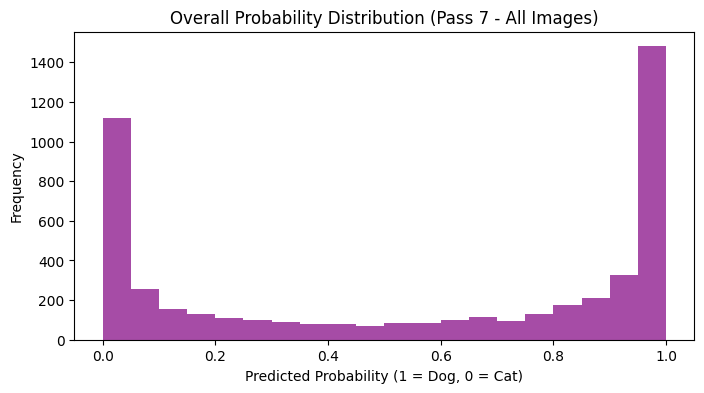

In [20]:
# Overall Probability Distributions

plt.figure(figsize=(8, 4))
plt.hist(test_predictions, bins=20, color='purple', alpha=0.7)
plt.title("Overall Probability Distribution (Pass 7 - All Images)")
plt.xlabel("Predicted Probability (1 = Dog, 0 = Cat)")
plt.ylabel("Frequency")
plt.show()

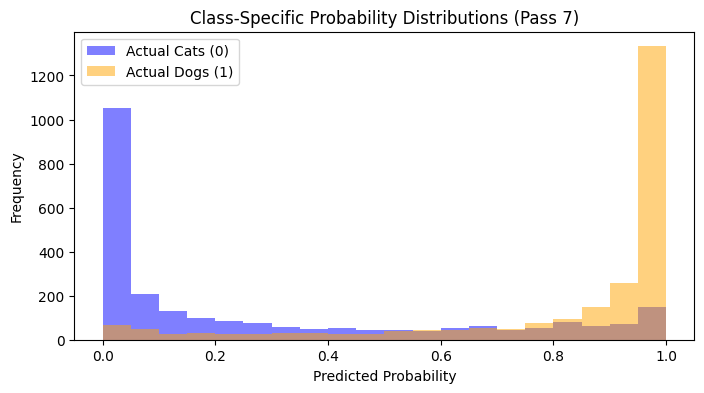

In [21]:
# Class-Specific Probability Distributions

plt.figure(figsize=(8, 4))
plt.hist(test_predictions[y_test == 0], bins=20, color='blue', alpha=0.5, label='Actual Cats (0)')
plt.hist(test_predictions[y_test == 1], bins=20, color='orange', alpha=0.5, label='Actual Dogs (1)')
plt.title("Class-Specific Probability Distributions (Pass 7)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [22]:
# High-Confidence False Positives (Actually Dog, Predicted Cat)

false_cats = np.where((y_test == 1) & (test_predictions < 0.1))[0]

# High-Confidence False Negatives (Actually Cat, Predicted Dog)

false_dogs = np.where((y_test == 0) & (test_predictions > 0.9))[0]

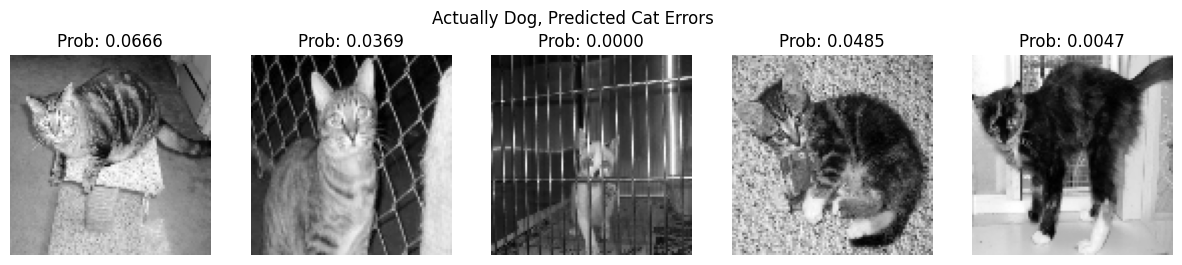

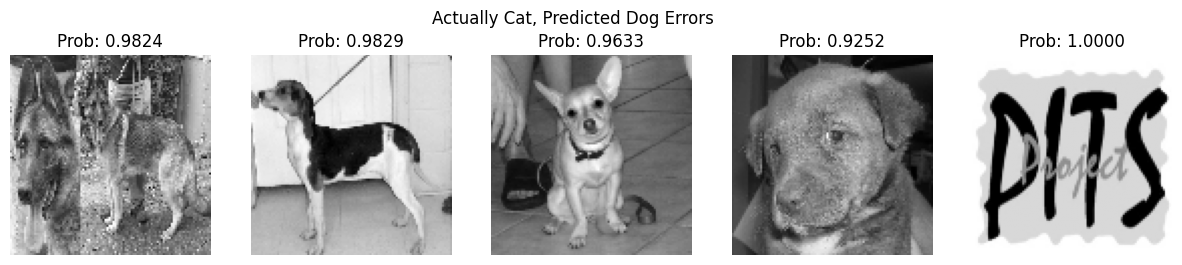

In [23]:
# Visually Inspecting Oddities

def plot_errors(error_indices, title_prefix):
    if len(error_indices) == 0:
        print(f"No {title_prefix} found at this confidence threshold.")
        return

    plt.figure(figsize=(15, 3))
    # Plot up to 5 errors
    plot_count = min(len(error_indices), 5)
    for i in range(plot_count):
        idx = error_indices[i]
        plt.subplot(1, 5, i+1)
        plt.imshow(X_test[idx].reshape(100, 100), cmap='gray')
        plt.title(f"Prob: {test_predictions[idx]:.4f}")
        plt.axis('off')
    plt.suptitle(f"{title_prefix} Errors")
    plt.show()

plot_errors(false_cats, "Actually Dog, Predicted Cat")
plot_errors(false_dogs, "Actually Cat, Predicted Dog")

## Hyperparameter Experimentation

For this final experiment, I apply Batch Normalization to stabilize the learning process and allow the model to converge faster, pairing it with heavy dropout to prevent the large dataset from causing overfitting

In [24]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

In [25]:
# Experimental Model: Adding Batch Normalization and deeper architecture

exp_model_7 = Sequential()

# Block 1

exp_model_7.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(100, 100, 1)))
exp_model_7.add(BatchNormalization())
exp_model_7.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2

exp_model_7.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
exp_model_7.add(BatchNormalization())
exp_model_7.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3

exp_model_7.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
exp_model_7.add(BatchNormalization())
exp_model_7.add(MaxPooling2D(pool_size=(2, 2)))

# Output Layer

exp_model_7.add(Flatten())
exp_model_7.add(Dense(128, activation='relu'))
exp_model_7.add(Dropout(0.5))
exp_model_7.add(Dense(1, activation='sigmoid'))

exp_model_7.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train with early stopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

exp_history_7 = exp_model_7.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.6469 - loss: 0.6778 - val_accuracy: 0.4974 - val_loss: 0.8180
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7611 - loss: 0.5023 - val_accuracy: 0.7267 - val_loss: 0.5454
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8083 - loss: 0.4275 - val_accuracy: 0.6567 - val_loss: 0.6128
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8444 - loss: 0.3576 - val_accuracy: 0.7343 - val_loss: 0.6376
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8705 - loss: 0.2985 - val_accuracy: 0.8265 - val_loss: 0.4159
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8915 - loss: 0.2516 - val_accuracy: 0.8543 - val_loss: 0.3353
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9105 - loss: 0.2094 - val_accuracy: 0.7317 - val_loss: 0.7051
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9263 - loss: 0.1744 - val_acc